In [1]:
#Terceros
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
#Este proyecto
import set_paths
from config.paths import RAW_DATA, CLEAN_DATA, GROUPED_DATA, SCORED_DATA
from config.config import paleta
from src.pipeline import full_treatment, get_top
from src.utils import extraer_sufijo_csv
from src.visuals import bar_plot, hist_plot

## SCORE
$$

score = w_1*(precio\, mediano\, m2) + w_2*(1 - edad\, anuncios\, promedio) + w_3*(1-coef.\, var)

$$

## TOP'S Y DISTRIBUCIONES DE PRECIOS POR ESTADO

In [2]:
mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 8.5,
})

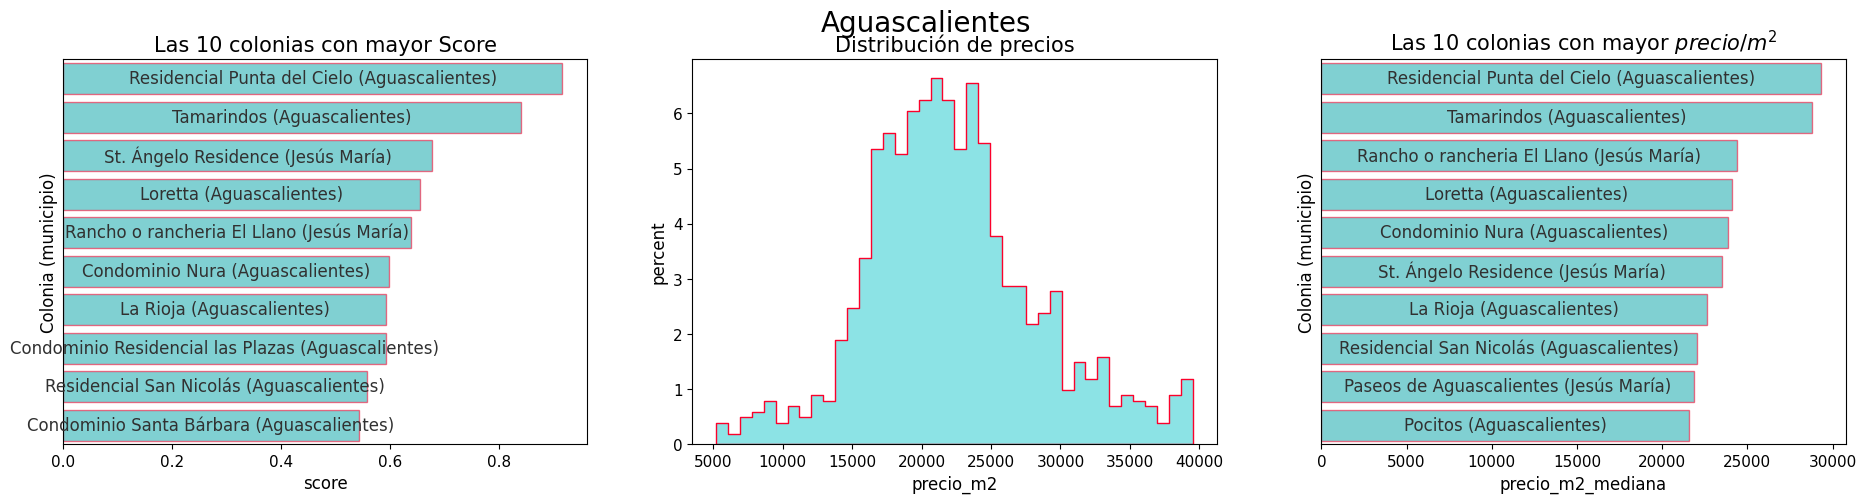

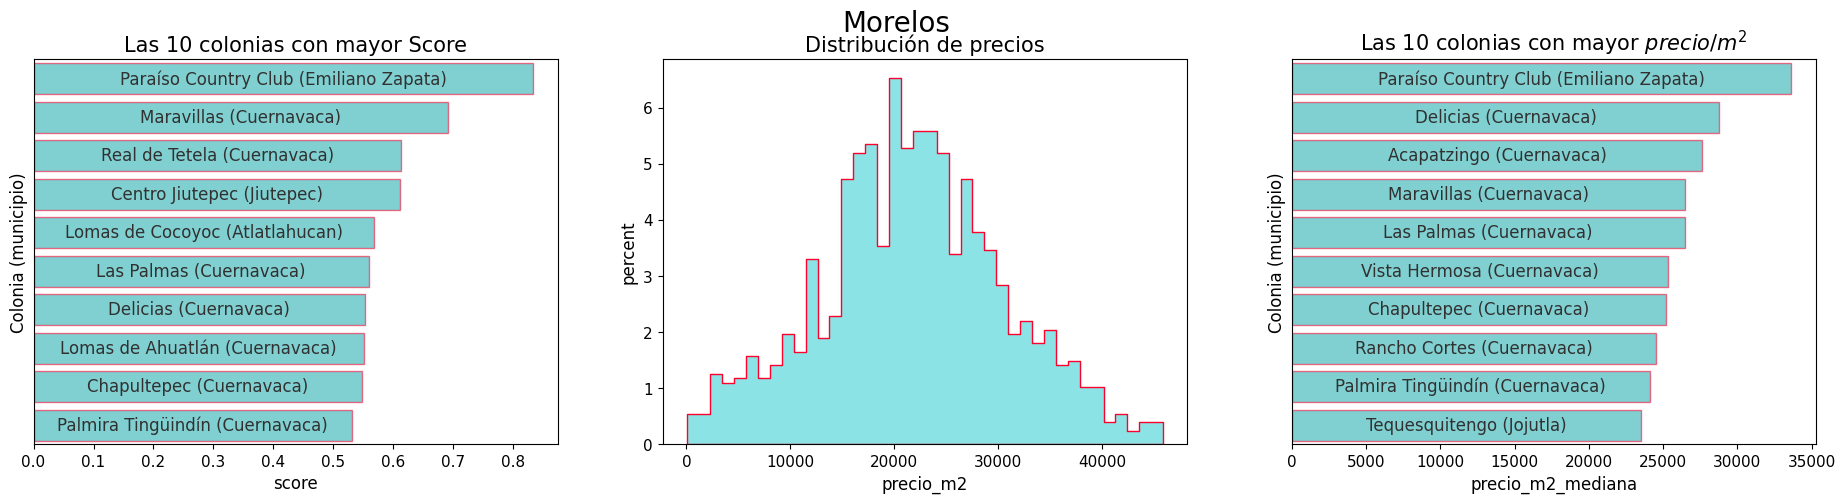

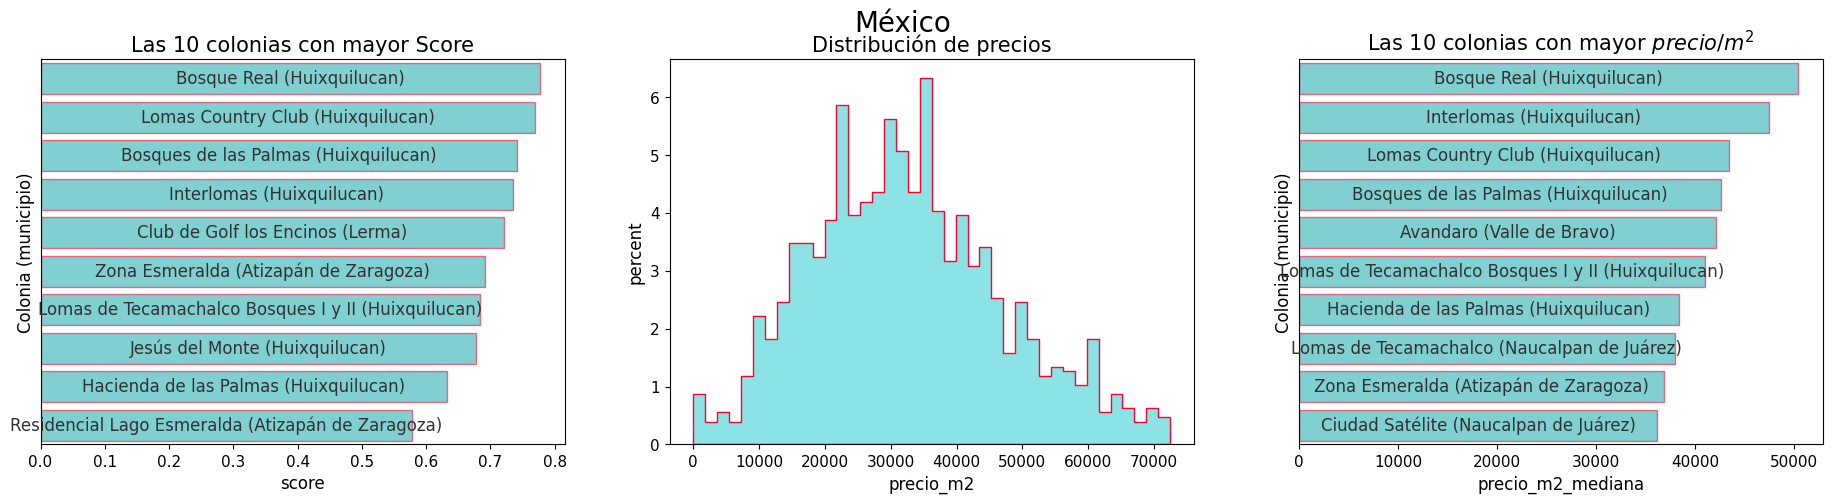

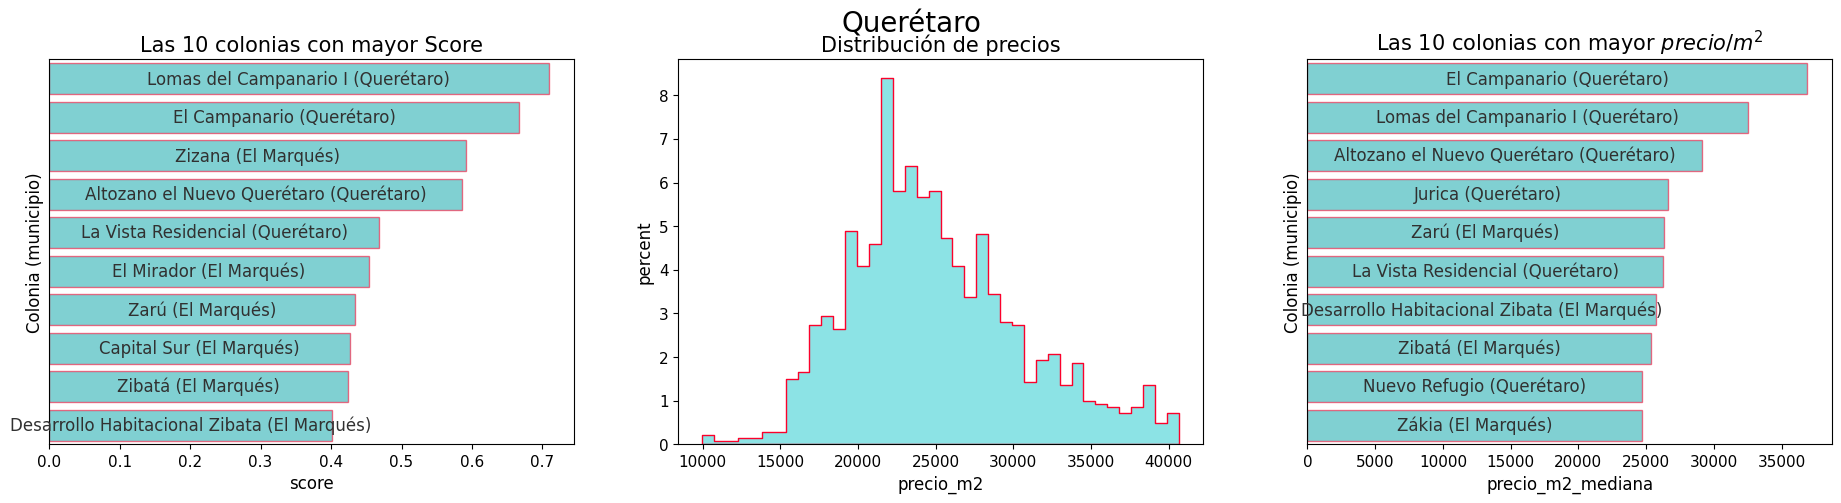

In [3]:
top = 10
raw_files = [state.name for state in RAW_DATA.iterdir() if state.is_file()]    
for state in raw_files:
    #test
    state_name = extraer_sufijo_csv(state)#RAW_DATA / "properties_Morelos.csv")
    
    #TRATAR Y CARGAR DATOS:
    normalized_mor = full_treatment(RAW_DATA / f"properties_{state_name}.csv")
    full_mor = pd.read_csv(CLEAN_DATA / f"clean_{state_name}.csv") 
    grouped_mor = pd.read_csv(GROUPED_DATA / f"grouped_{state_name}.csv")
    top_score = get_top(normalized_mor, top = top, criterion= "score")
    top_price = get_top(grouped_mor, top = top, criterion= "precio_m2_mediana")

    #VISUALIZACIÓN:
    fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (23,5))
    plt.suptitle(f"{state_name}", fontsize = 20)
    #TOP MEJOR SCORE
    barplot = bar_plot( data = top_score, 
                        criterion= "score", 
                        barplot_args= {"color" : paleta["principal"], "edgecolor" : paleta["contraste"], "alpha": 0.55}, 
                        title = f"Las {top} colonias con mayor Score", 
                        ax=axes[0])
    
    #DISTRIBUCIÓN DE PRECIOS POR ESTADO
    histplot = hist_plot(data = full_mor, 
                         column = "precio_m2", 
                         title = f"Distribución de precios",
                         ax = axes[1],
                         histplot_args = {"stat":"percent", 
                                          "color" : paleta["principal"], 
                                          "edgecolor" : paleta["contraste"], 
                                          "alpha": 0.45, 
                                          "element": "step", 
                                          "bins": 40})
    
    #TOP PRECIO/M2 MÁS ALTO
    barplot = bar_plot( data = top_price, 
                        criterion= "precio_m2_mediana", 
                        barplot_args= {"color" : paleta["principal"], "edgecolor" : paleta["contraste"], "alpha": 0.55}, 
                        title = fr"Las {top} colonias con mayor $precio/m^2$", 
                        ax=axes[2])
    plt.show()
    #plt.tight_layout()